In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA PREPROCESSING

In [ ]:
df= pd.read_csv('/content/train.csv') #loading the dataset
test=pd.read_csv('/content/test.csv')

In [ ]:
df.head(10)#viewing the first 10 rows

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
6,6,qp02zy,48,0:0,0.042247,Residential,3,Allowed,Yes,15.772408,Foggy
7,7,qp08by,48,0:0,0.040135,Residential,1,Not Allowed,No,2.705143,Snowy
8,8,qp08gq,48,0:0,0.001002,Residential,1,Not Allowed,No,18.136899,Foggy
9,9,qp08gy,48,0:0,0.003948,Residential,3,Allowed,Yes,12.738209,Rainy


In [ ]:
df.info() #basic info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [ ]:
df.describe() #description of the data

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [ ]:
df.shape


(77299, 11)

In [ ]:
df['geohash'].unique().size  #reading the unique values of each of these columns
df['day'].unique()
df['timestamp'].unique()
df['RoadType'].unique()
df['Weather'].unique()

array([nan, 'Sunny', 'Rainy', 'Foggy', 'Snowy'], dtype=object)

In [ ]:
df.isnull().sum()  #checking the number of null values in the dataset

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


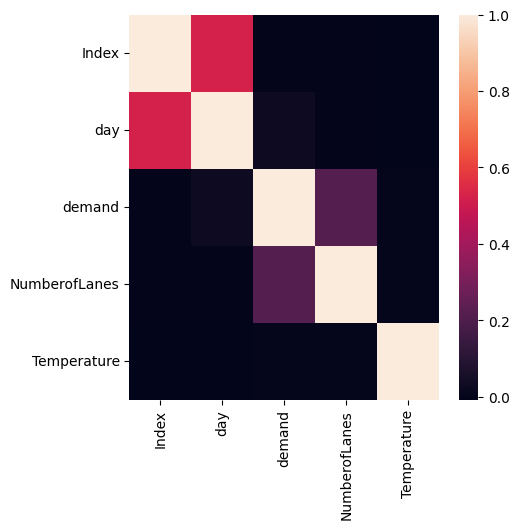

In [ ]:
col= pd.DataFrame(df.select_dtypes(include=['number'])) #checking the correlation of the columns
plt.figure(figsize=(5,5))
sns.heatmap(col.corr())
plt.show()

/tmp/ipykernel_4171/1325947746.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i],palette='viridis')


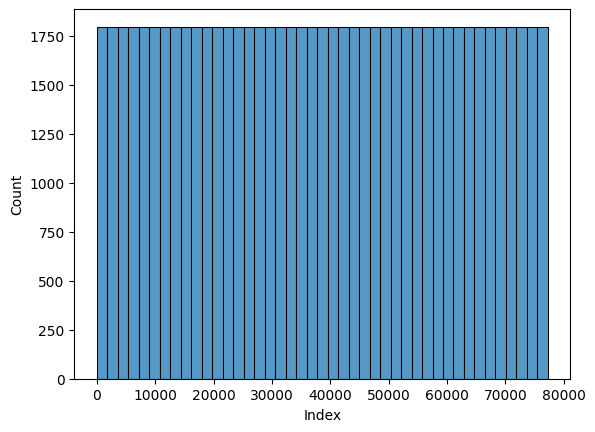

/tmp/ipykernel_4171/1325947746.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i],palette='viridis')


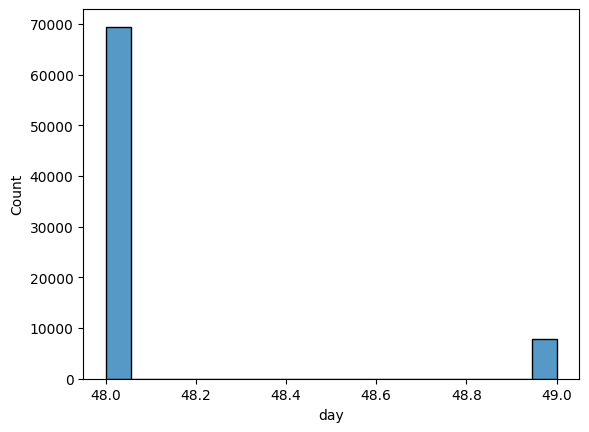

/tmp/ipykernel_4171/1325947746.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i],palette='viridis')


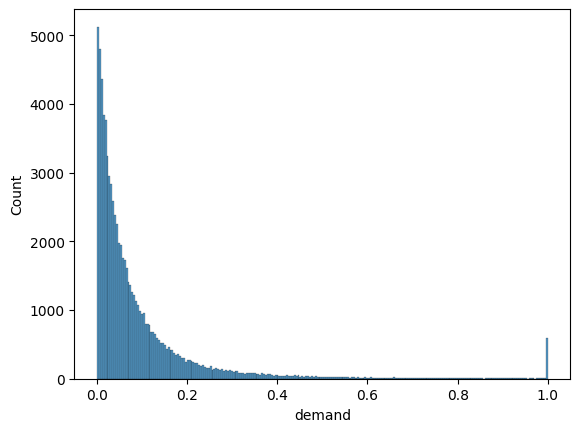

/tmp/ipykernel_4171/1325947746.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i],palette='viridis')


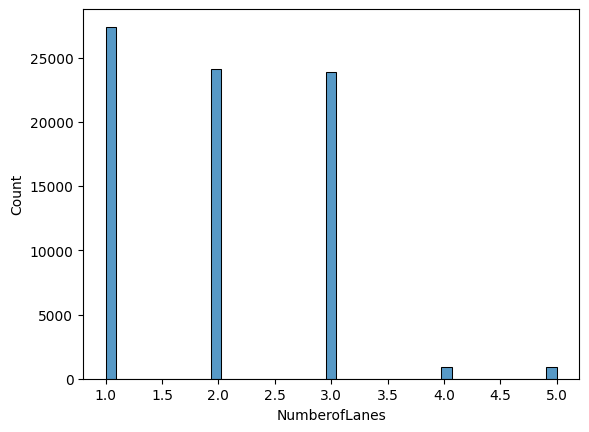

/tmp/ipykernel_4171/1325947746.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[i],palette='viridis')


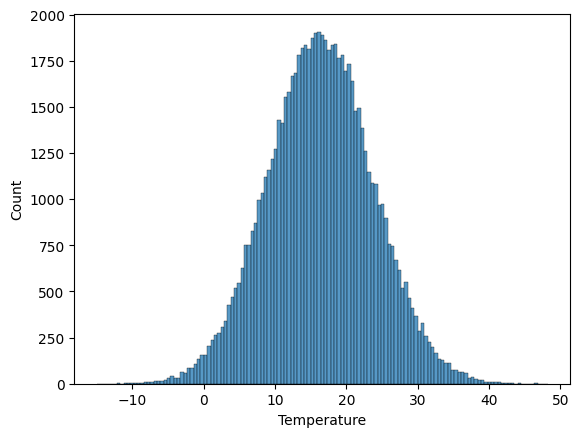

In [ ]:
for i in df.select_dtypes(include=['number']) :#viewing the histrogram plots of numerical columns
  sns.histplot(df[i],palette='viridis')
  plt.show()

/tmp/ipykernel_4171/3347403371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[i],palette='viridis')


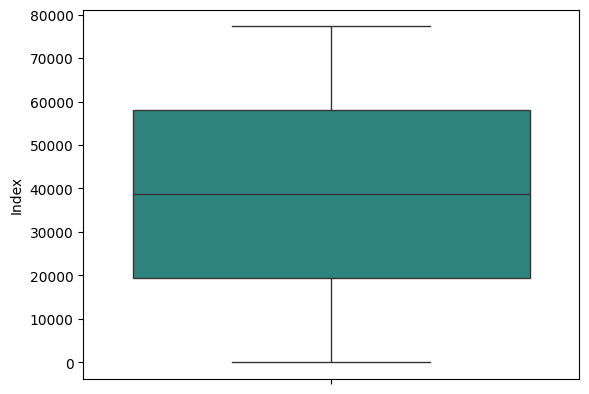

/tmp/ipykernel_4171/3347403371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[i],palette='viridis')


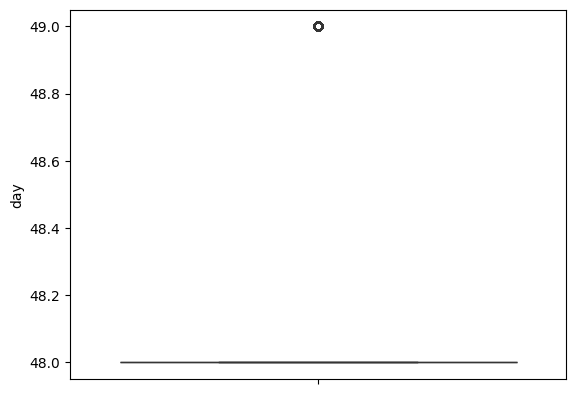

/tmp/ipykernel_4171/3347403371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[i],palette='viridis')


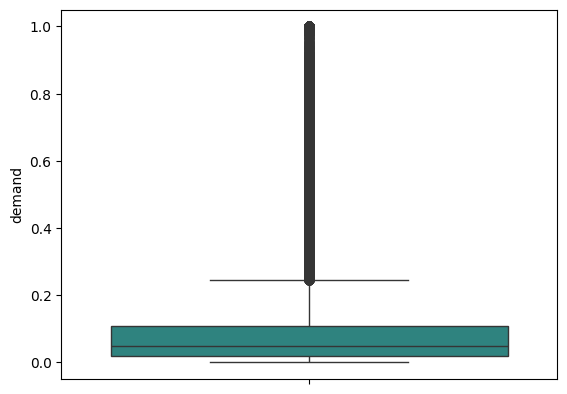

/tmp/ipykernel_4171/3347403371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[i],palette='viridis')


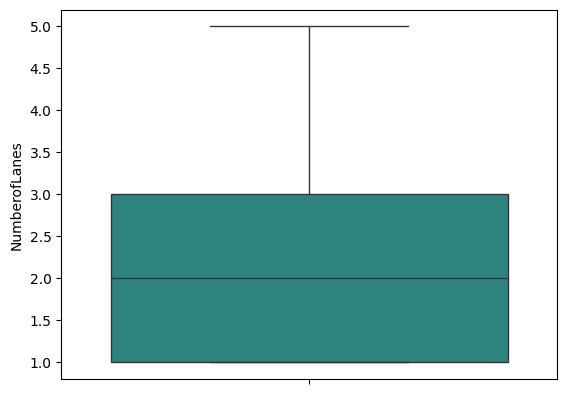

/tmp/ipykernel_4171/3347403371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df[i],palette='viridis')


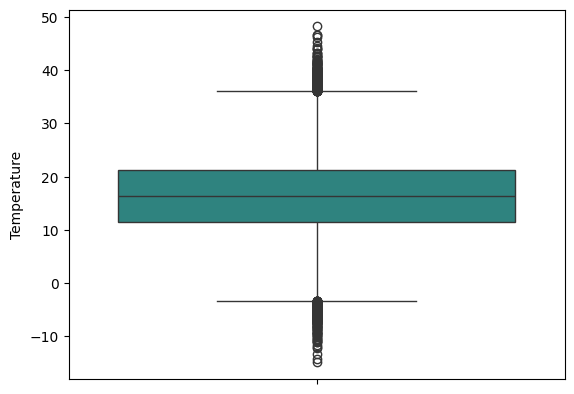

In [ ]:
for i in df.select_dtypes(include=['number']) :#viewing the boxplot graphds of numerical columns
  sns.boxplot(df[i],palette='viridis')
  plt.show()

/tmp/ipykernel_4171/120525654.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df[i],palette='viridis')


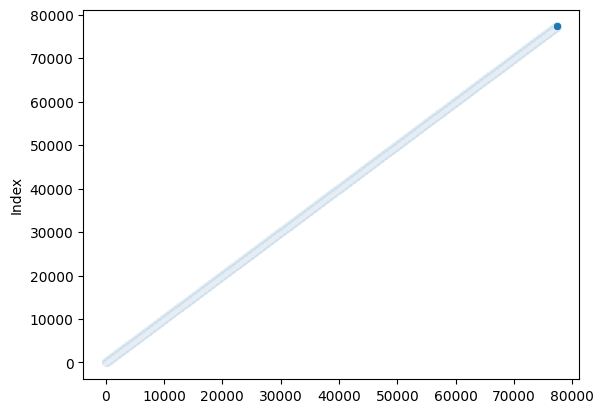

/tmp/ipykernel_4171/120525654.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df[i],palette='viridis')


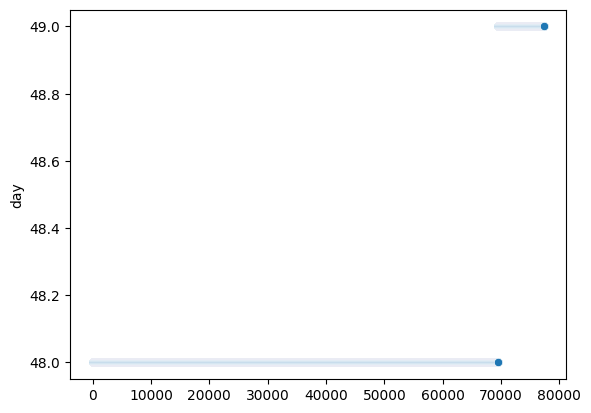

/tmp/ipykernel_4171/120525654.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df[i],palette='viridis')


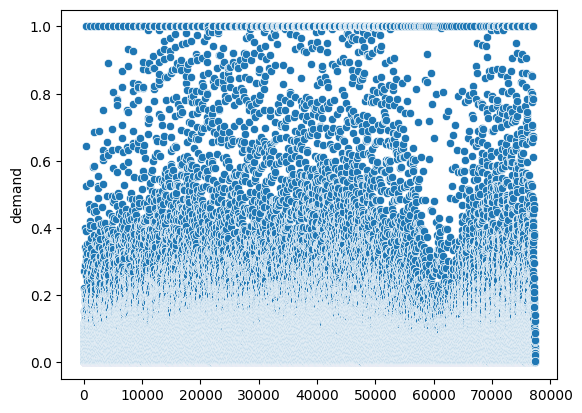

/tmp/ipykernel_4171/120525654.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df[i],palette='viridis')


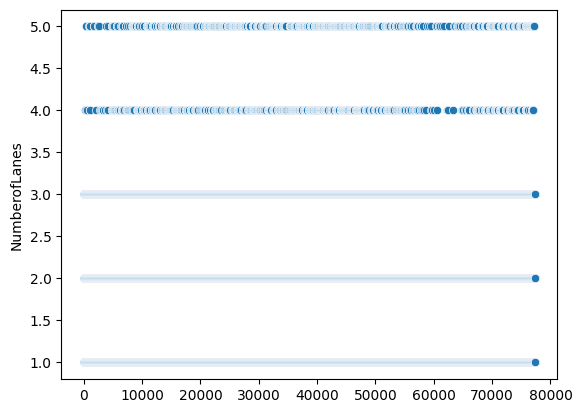

/tmp/ipykernel_4171/120525654.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df[i],palette='viridis')


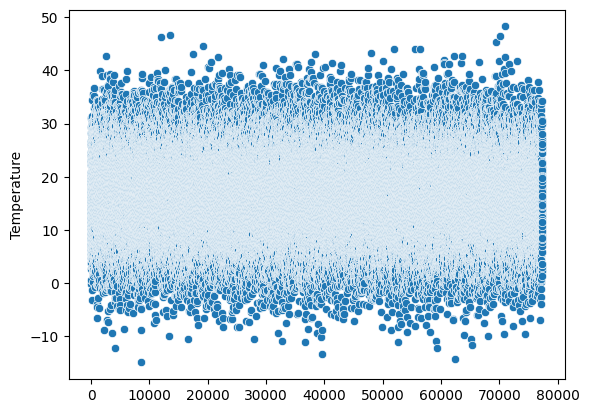

In [ ]:

for i in df.select_dtypes(include=['number']) :#viewing the scatter plots of numerical columnds
  sns.scatterplot(df[i],palette='viridis')
  plt.show()


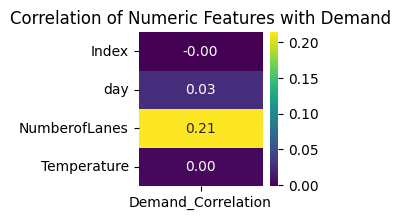

In [ ]:
correlations = {}
for col in df.select_dtypes(include='number').columns:
  if col != 'demand': # Excluding 'demand' from correlating with itself if it's in the numeric columns
    correlations[col] = df[col].corr(df['demand'])

correlation_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Demand_Correlation'])

plt.figure(figsize=(2, len(correlation_df) * 0.5)) # Adjusting figure size for better visualization
sns.heatmap(correlation_df, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation of Numeric Features with Demand')
plt.yticks(rotation=0)
plt.show()

In [ ]:
#outlier capping
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

# Defining the upper and lower bounds for outlier capping
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# Capping the outliers in the 'Temperature' column
    df['Temperature'] = np.where(df['Temperature'] < lower_bound, lower_bound, df['Temperature'])
    df['Temperature'] = np.where(df['Temperature'] > upper_bound, upper_bound, df['Temperature'])

    print(f"Temperature outliers capped. New min: {df['Temperature'].min():.2f}, new max: {df['Temperature'].max():.2f}")

# Verify the changes by re-plotting the boxplot for Temperature
detect_outliers(df, 'Temperature')
detect_outliers(test, 'Temperature')


Temperature outliers capped. New min: -3.37, new max: 36.10
Temperature outliers capped. New min: -3.23, new max: 36.12


In [ ]:

df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M')
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['is_rush'] = df['hour'].isin([7, 8, 9, 17, 18, 19])
df['is_night']= df['hour'].isin ([22,23,0,1,2,3,4,5])
df['is_lunch_hour']  = df['hour'].isin ([12, 13])
test['timestamp'] = pd.to_datetime(test['timestamp'], format='%H:%M')
test['hour'] = test['timestamp'].dt.hour
test['minute'] = test['timestamp'].dt.minute
test['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
test['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
test['is_rush'] = test['hour'].isin([7, 8, 9, 17, 18, 19])
test['is_night']= test['hour'].isin ([22,23,0,1,2,3,4,5])
test['is_lunch_hour']  = test['hour'].isin ([12, 13])

In [ ]:
#filling null values with the mean of the column
mean_temp = df['Temperature'].mean()
df['Temperature'] = df['Temperature'].fillna(mean_temp)
test['Temperature'] = test['Temperature'].fillna(test['Temperature'].mean())

# Verifying that the nulls in 'Temperature' are handled
print(f"Nulls in 'Temperature' after imputation: {df['Temperature'].isnull().sum()}")

Nulls in 'Temperature' after imputation: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
#categorical values assigned numberical values for processing
oe=OrdinalEncoder()
road_map = {"Residential": 0, "Street": 1, "Highway": 2}
df["RoadType_ord"] = df["RoadType"].map(road_map)
le = LabelEncoder()
df['day'] = le.fit_transform(df['day'])

test['Weather'] = le.fit_transform(test['Weather'])
road_map = {"Residential": 0, "Street": 1, "Highway": 2}
test["RoadType_ord"] = test["RoadType"].map(road_map)
le = LabelEncoder()
test['day'] = le.fit_transform(test['day'])

test['Weather'] = le.fit_transform(test['Weather'])


In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.9 MB/s eta 0:00:00


In [ ]:
from category_encoders import BinaryEncoder

original_cols_to_binary_encode = ['is_rush', 'is_night', 'Landmarks', 'LargeVehicles', 'is_lunch_hour']

# Identifying which of the original columns are still present in df
columns_to_encode_in_df = [col for col in original_cols_to_binary_encode if col in df.columns]

# Identifying which of the original columns are still present in test
columns_to_encode_in_test = [col for col in original_cols_to_binary_encode if col in test.columns]

if columns_to_encode_in_df:
    be = BinaryEncoder(cols=columns_to_encode_in_df)
    df = be.fit_transform(df)
    print(f"Binary encoding applied to df DataFrame for columns: {columns_to_encode_in_df}")
else:
    print("All specified columns for binary encoding are already processed or do not exist in the df DataFrame.")

if columns_to_encode_in_test:
    # Use the same encoder fitted on df to transform test for consistency
    test = be.transform(test)
    print(f"Binary encoding applied to test DataFrame for columns: {columns_to_encode_in_test}")
else:
    print("All specified columns for binary encoding are already processed or do not exist in the test DataFrame.")

Binary encoding applied to df DataFrame for columns: ['is_rush', 'is_night', 'Landmarks', 'LargeVehicles', 'is_lunch_hour']
All specified columns for binary encoding are already processed or do not exist in the test DataFrame.


In [ ]:
df.head(10)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,is_rush,is_night,is_lunch_hour,RoadType_ord
0,0,qp02z1,0,1900-01-01,0.048804,NaN,1,Not Allowed,No,16.404524,NaN,0,0,0.0,1.0,False,True,False,NaN
1,1,qp02zt,0,1900-01-01,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0.0,1.0,False,True,False,0.0
2,2,qp08bj,0,1900-01-01,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0.0,1.0,False,True,False,0.0
3,3,qp08gt,0,1900-01-01,0.003272,Residential,1,Not Allowed,No,16.404524,Rainy,0,0,0.0,1.0,False,True,False,0.0
4,4,qp02zq,0,1900-01-01,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0.0,1.0,False,True,False,0.0
5,5,qp02zw,0,1900-01-01,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy,0,0,0.0,1.0,False,True,False,0.0
6,6,qp02zy,0,1900-01-01,0.042247,Residential,3,Allowed,Yes,15.772408,Foggy,0,0,0.0,1.0,False,True,False,0.0
7,7,qp08by,0,1900-01-01,0.040135,Residential,1,Not Allowed,No,2.705143,Snowy,0,0,0.0,1.0,False,True,False,0.0
8,8,qp08gq,0,1900-01-01,0.001002,Residential,1,Not Allowed,No,18.136899,Foggy,0,0,0.0,1.0,False,True,False,0.0
9,9,qp08gy,0,1900-01-01,0.003948,Residential,3,Allowed,Yes,12.738209,Rainy,0,0,0.0,1.0,False,True,False,0.0


In [ ]:
df["geo_p5"] = df["geohash"].str[:5]#neighbour
df["geo_p4"] = df["geohash"].str[:4]#district
df["geo_p6"] = df["geohash"].str[:6]#street
test['geo_p5']= df['geo_p5'].str[:5]
test['geo_p6']=df['geo_p6'].str[:6]
test['geo_p4']=df['geo_p4'].str[:4]



In [ ]:
df['demand'].min()

6.245650130093708e-07

In [ ]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,0


FEATURE ENGINEERING

In [ ]:
def structural_features(df):
    df = df.copy()
    df["is_highway"]     = (df["RoadType_ord"] == 2).astype(int)
    df["is_residential"] = (df["RoadType_ord"] == 0).astype(int)
    df["is_street"]      = (df["RoadType_ord"] == 1).astype(int)
    df["high_capacity"] = (
        (df["is_highway"] == 1) &
        (df["NumberofLanes"] >= 4)
    ).astype(int)

    # Dynamically create LargeVehicles_0 if it doesn't exist (i.e., if binary encoding wasn't applied yet)
    if 'LargeVehicles_0' not in df.columns and 'LargeVehicles' in df.columns:
        # Assuming 'LargeVehicles_0' corresponds to 'Allowed' status
        df['LargeVehicles_0'] = (df['LargeVehicles'] == 'Allowed').astype(int)
    elif 'LargeVehicles_0' not in df.columns and 'LargeVehicles' not in df.columns:
        # Fallback if neither exists (should not happen with current data)
        df['LargeVehicles_0'] = 0 # Or handle as appropriate, e.g., error or mean imputation

    # Corrected: Assuming only one of LargeVehicles_0 or LargeVehicles_1 is needed
    # and that df["LargeVehicles_0"] is the intended feature for 'Allowed' status.
    df["road_capacity_score"] = (
        df["NumberofLanes"] * (1 + df["LargeVehicles_0"]) * df["is_highway"]
    )


    df["lanes_squared"] = df["NumberofLanes"] ** 2

    # Dynamically create is_rush_0 if it doesn't exist
    if 'is_rush_0' not in df.columns and 'is_rush' in df.columns:
        df['is_rush_0'] = df['is_rush'].astype(int)
    elif 'is_rush_0' not in df.columns and 'is_rush' not in df.columns:
        df['is_rush_0'] = 0

    # Dynamically create is_lunch_hour_0 if it doesn't exist
    if 'is_lunch_hour_0' not in df.columns and 'is_lunch_hour' in df.columns:
        df['is_lunch_hour_0'] = df['is_lunch_hour'].astype(int)
    elif 'is_lunch_hour_0' not in df.columns and 'is_lunch_hour' not in df.columns:
        df['is_lunch_hour_0'] = 0

    df["highway_rush"] = df["is_highway"] * df["is_rush_0"]


    df["highway_lunch_hour"] = df["is_highway"] * df["is_lunch_hour_0"]


    df["highway_x_hour"]  = df["is_highway"] * df["hour"]


    df["residential_evening"] = df["is_residential"] * df["is_rush_0"]

    return df

train = structural_features(df)
test=structural_features(test)

In [ ]:
def temperature_features(df, global_temp_mean=16.4):
    df = df.copy()

    # Filling missing temperature with global mean
    df["Temperature"] = df["Temperature"].fillna(global_temp_mean)

    # Temperature bins (5 equal-width bins)
    df["temp_bin"] = pd.cut(
        df["Temperature"],
        bins=[-20, 0, 10, 20, 30, 50],
        labels=[0, 1, 2, 3, 4]
    ).astype(float).fillna(2)

    # Extreme temperature flag
    # Very cold (<0) or very hot (>35) might affect travel
    df["extreme_temp"] = (
        (df["Temperature"] < 0) | (df["Temperature"] > 35)
    ).astype(int)

    # Temperature × road type interaction
    # Cold weather might affect highway demand differently
    df["temp_x_highway"] = df["Temperature"] * df["is_highway"]

    return df

global_temp_mean = train["Temperature"].mean()
train = temperature_features(train, global_temp_mean)
test = temperature_features(test, test["Temperature"].mean())


In [ ]:
def target_encode(train_fold, val_fold,test_data, col, demand, smoothing=10):

    global_mean = train_fold[demand].mean()

    stats = train_fold.groupby(col)[demand].agg(["mean", "count"])
    stats.columns = ["mean", "count"]

    # Smoothing formula:
    # encoded = (n * category_mean + smoothing * global_mean) / (n + smoothing)
    stats["smoothed"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean) /
        (stats["count"] + smoothing)
    )

    train_enc = val_fold[col].map(stats["smoothed"]).fillna(global_mean)
    test_enc  = test_data[col].map(stats["smoothed"]).fillna(global_mean)


    return train_enc.values,test_enc.values


In [ ]:
p4_map = {g: i for i, g in enumerate(df["geo_p4"].unique())}
df["geo_p4_enc"] = df["geo_p4"].map(p4_map)
test["geo_p4_enc"] = test["geo_p4"].map(p4_map)

In [ ]:
def geo_agg_features(combined_df, train_df, geo_col, target="demand"):
    combined_df = combined_df.copy()
    train_df = train_df.copy()
    global_mean_target = train_df[target].mean()

    agg = train_df.groupby(geo_col)[target].agg(
        mean   = "mean",
        std    = "std",
        median = "median",
        max    = "max",
        min    = "min",
        count  = "count"
    ).reset_index()

    agg.columns = [geo_col] + [f"{geo_col}_{s}"
                   for s in ["mean", "std", "median", "max", "min", "count"]]

    # std can be NaN for single-row groups
    agg[f"{geo_col}_std"] = agg[f"{geo_col}_std"].fillna(0)

    combined_df = combined_df.merge(agg, on=geo_col, how="left")

    # Fill any test rows whose geo wasn't in train
    for s in ["mean", "std", "median", "max", "min"]:
        col = f"{geo_col}_{s}"
        combined_df[col] = combined_df[col].fillna(global_mean_target)
    combined_df[f"{geo_col}_count"] = combined_df[f"{geo_col}_count"].fillna(0)

    return combined_df

# Define the TARGET variable
TARGET = 'demand'

# Combine for consistent feature creation
combined = pd.concat([
    train.drop(columns=[TARGET]),
    test
], axis=0).reset_index(drop=True)

# Add geo agg stats for p5 (most reliable — 1380 avg rows)
combined = geo_agg_features(combined, train, "geo_p5", TARGET)

# Add geo agg stats for p6 (granular but sparse — 62 avg rows)
combined = geo_agg_features(combined, train, "geo_p6", TARGET)

In [ ]:
def location_time_interactions(df):
    df = df.copy()

    # Location's avg demand × time bucket
    # "This neighborhood is busy AND it's peak hour"
    # Using 'is_rush_0' after binary encoding
    df["geo_mean_x_evening"] = df["geo_p5_mean"] * df["is_rush_0"]
    df["geo_mean_x_morning"] = df["geo_p5_mean"] * df["is_rush_0"]
    df["geo_mean_x_hour"]    = df["geo_p5_mean"] * df["hour_sin"]

    # Location volatility — how unpredictable is this spot?
    # High std = demand fluctuates a lot → harder to predict
    df["geo_cv"] = df["geo_p5_std"] / (df["geo_p5_mean"] + 1e-6)

    # Location × road type
    # "This neighborhood + highway" — is this a highway-heavy area?
    df["geo_x_highway"] = df["geo_p5_mean"] * df["is_highway"]

    # Demand potential score — composite of location + road
    df["demand_potential"] = (
        df["geo_p5_mean"] * df["RoadType_ord"] * (df["NumberofLanes"] + 1)
    )

    return df

combined = location_time_interactions(combined)

In [ ]:
#dropping redundant columns
ID_COL = 'Index'

DROP_COLS = [
    "timestamp",      # replaced by hour, minute, time features
    "minute",         # zero signal (all 15-min intervals identical)
    "RoadType",       # replaced by RoadType_ord + is_highway etc
    "Weather",        # replaced by Weather_enc
    "LargeVehicles",  # redundant with LargeVehicles_0/1
    "Landmarks",      # redundant with Landmarks_0/1
    "is_rush",        # redundant with is_rush_0/1
    "is_night",       # redundant with is_night_0/1
    "is_lunch_hour",  # redundant with is_lunch_hour_0/1
    "geohash",        # replaced by geo_p4/p5/p6 + aggregation stats
    "geo_p4",         # replaced by geo_p4_enc
    "geo_p5",         # used for agg stats, raw string not needed
    "geo_p6",         # used for agg stats, raw string not needed
    ID_COL,
]
DROP_COLS = [c for c in DROP_COLS if c in combined.columns]
combined.drop(columns=DROP_COLS, inplace=True)

print("\nFinal feature list:")
for i, col in enumerate(combined.columns):
    print(f"  {i+1:>2}. {col}")
print(f"\nTotal features: {combined.shape[1]}")


Final feature list:
   1. day
   2. NumberofLanes
   3. Temperature
   4. hour
   5. hour_sin
   6. hour_cos
   7. RoadType_ord
   8. is_highway
   9. is_residential
  10. is_street
  11. high_capacity
  12. LargeVehicles_0
  13. road_capacity_score
  14. lanes_squared
  15. is_rush_0
  16. is_lunch_hour_0
  17. highway_rush
  18. highway_lunch_hour
  19. highway_x_hour
  20. residential_evening
  21. temp_bin
  22. extreme_temp
  23. temp_x_highway
  24. LargeVehicles_1
  25. Landmarks_0
  26. Landmarks_1
  27. is_rush_1
  28. is_night_0
  29. is_night_1
  30. is_lunch_hour_1
  31. geo_p4_enc
  32. geo_p5_mean
  33. geo_p5_std
  34. geo_p5_median
  35. geo_p5_max
  36. geo_p5_min
  37. geo_p5_count
  38. geo_p6_mean
  39. geo_p6_std
  40. geo_p6_median
  41. geo_p6_max
  42. geo_p6_min
  43. geo_p6_count
  44. geo_mean_x_evening
  45. geo_mean_x_morning
  46. geo_mean_x_hour
  47. geo_cv
  48. geo_x_highway
  49. demand_potential

Total features: 49


BUILDING THE MODEL USING XGBOOST AND LIGHTGBM

In [ ]:
X_train = combined.iloc[:len(train)].reset_index(drop=True)
X_test  = combined.iloc[len(train):].reset_index(drop=True)
y_train = train[TARGET].values

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train range: [{y_train.min():.4f}, {y_train.max():.4f}]")
#MODEL WITH TARGET ENCODING INSIDE CV
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

# Target encode these columns inside CV
TE_COLS = ["geo_p5_enc_te", "geo_p6_enc_te"]

# Re-attaching raw geo cols for target encoding inside folds
X_train["_geo_p5"] = train["geo_p5"].values
X_train["_geo_p6"] = train["geo_p6"].values
X_test["_geo_p5"]  = test["geo_p5"].values
X_test["_geo_p6"]  = test["geo_p6"].values

# Also re-attaching to train df for reference inside loop
train["geo_p5"] = train["geohash"].str[:5]
train["geo_p6"] = train["geohash"]

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb  = np.zeros(len(X_train))
oof_xgb  = np.zeros(len(X_train))
pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))

lgb_params = dict(
    n_estimators     = 2000,
    learning_rate    = 0.03,
    num_leaves       = 63,
    max_depth        = -1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda        = 1.0,
    min_child_samples= 20,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

xgb_params = dict(
    n_estimators     = 2000,
    learning_rate    = 0.03,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    min_child_weight = 5,
    random_state     = 42,
    n_jobs           = -1,
)

print("\n── Training with 5-Fold CV ──")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    Xtr,  Xval  = X_train.iloc[tr_idx].copy(), X_train.iloc[val_idx].copy()
    Xte         = X_test.copy()
    ytr,  yval  = y_train[tr_idx], y_train[val_idx]

    # Target encoding geo_p5 inside fold
    tr_ref = train.iloc[tr_idx]  # reference df with raw geo cols + target

    for geo_raw, new_col in [("geo_p5", "geo_p5_te"), ("geo_p6", "geo_p6_te")]:
        global_mean = ytr.mean()
        stats = pd.DataFrame({"geo": tr_ref[geo_raw].values, "target": ytr})
        stats = stats.groupby("geo")["target"].agg(["mean", "count"])
        smoothing = 20 if geo_raw == "geo_p6" else 10  # more smoothing for sparse p6
        stats["smoothed"] = (
            (stats["count"] * stats["mean"] + smoothing * global_mean) /
            (stats["count"] + smoothing)
        )

        geo_map = stats["smoothed"].to_dict()
        raw_col = f"_{geo_raw}"

        Xtr[new_col]  = Xtr[raw_col].map(geo_map).fillna(global_mean)
        Xval[new_col] = Xval[raw_col].map(geo_map).fillna(global_mean)
        Xte[new_col]  = Xte[raw_col].map(geo_map).fillna(global_mean)

    # Dropping geo helper columns
    drop_raw = ["_geo_p5", "_geo_p6"]
    Xtr  = Xtr.drop(columns=drop_raw)
    Xval = Xval.drop(columns=drop_raw)
    Xte  = Xte.drop(columns=drop_raw)

    #LightGBM modelling
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    lgb_model.fit(
        Xtr, ytr,
        eval_set=[(Xval, yval)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    oof_lgb[val_idx] = lgb_model.predict(Xval)
    pred_lgb        += lgb_model.predict(Xte) / N_FOLDS

    #XGBoost modelling
    xgb_model = xgb.XGBRegressor(**xgb_params)
    xgb_model.fit(
        Xtr, ytr,
        eval_set=[(Xval, yval)],
        verbose=False
    )
    oof_xgb[val_idx] = xgb_model.predict(Xval)
    pred_xgb        += xgb_model.predict(Xte) / N_FOLDS

    lgb_rmse = np.sqrt(mean_squared_error(yval, oof_lgb[val_idx]))
    xgb_rmse = np.sqrt(mean_squared_error(yval, oof_xgb[val_idx]))
    print(f"  Fold {fold+1} | LGB RMSE: {lgb_rmse:.5f} | XGB RMSE: {xgb_rmse:.5f}")


lgb_oof_rmse = np.sqrt(mean_squared_error(y_train, oof_lgb))
xgb_oof_rmse = np.sqrt(mean_squared_error(y_train, oof_xgb))

w_lgb = 1 / lgb_oof_rmse
w_xgb = 1 / xgb_oof_rmse
w_sum = w_lgb + w_xgb

oof_blend  = (w_lgb * oof_lgb  + w_xgb * oof_xgb)  / w_sum
pred_blend = (w_lgb * pred_lgb + w_xgb * pred_xgb) / w_sum

# Clip predictions to valid range [0, 1]
pred_blend = np.clip(pred_blend, 0, 1)
oof_blend  = np.clip(oof_blend,  0, 1)

blend_rmse = np.sqrt(mean_squared_error(y_train, oof_blend))
blend_r2   = r2_score(y_train, oof_blend)

print(f"\n── Final Results ──")
print(f"  LGB  OOF RMSE : {lgb_oof_rmse:.5f}")
print(f"  XGB  OOF RMSE : {xgb_oof_rmse:.5f}")
print(f"  Blend OOF RMSE: {blend_rmse:.5f}")
print(f"  Blend OOF R²  : {blend_r2:.5f}  ({blend_r2*100:.2f}%)")


X_train: (77299, 49)
X_test : (41778, 49)
y_train range: [0.0000, 1.0000]

── Training with 5-Fold CV ──
  Fold 1 | LGB RMSE: 0.02899 | XGB RMSE: 0.02964
  Fold 2 | LGB RMSE: 0.02969 | XGB RMSE: 0.03026
  Fold 3 | LGB RMSE: 0.02904 | XGB RMSE: 0.02914
  Fold 4 | LGB RMSE: 0.02946 | XGB RMSE: 0.03026
  Fold 5 | LGB RMSE: 0.02875 | XGB RMSE: 0.02933

── Final Results ──
  LGB  OOF RMSE : 0.02919
  XGB  OOF RMSE : 0.02973
  Blend OOF RMSE: 0.02924
  Blend OOF R²  : 0.95773  (95.77%)



── Blended Model Evaluation ──
  R²   : 0.95773  →  95.77%  (your 'accuracy')
  RMSE : 0.02924
  MAE  : 0.01948


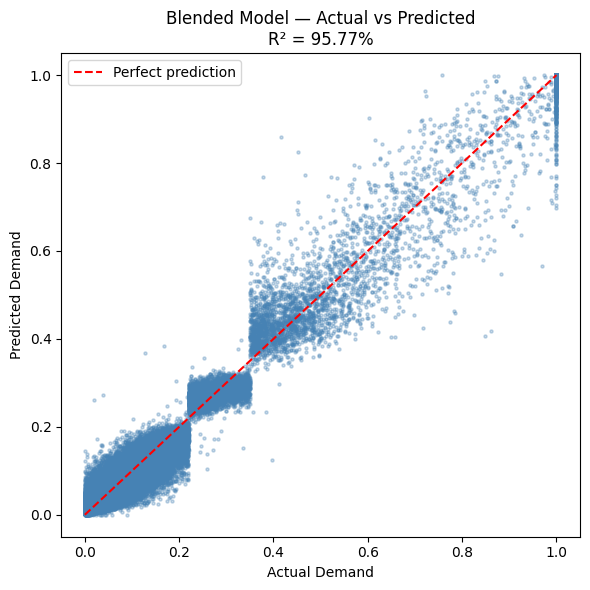

In [ ]:
from sklearn.metrics import mean_absolute_error

def evaluate_model(y_true, y_pred, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n── {label} Evaluation ──")
    print(f"  R²   : {r2:.5f}  →  {r2*100:.2f}%  (your 'accuracy')")
    print(f"  RMSE : {rmse:.5f}")
    print(f"  MAE  : {mae:.5f}")

    # Visual checking — actual vs predicted scatter
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, s=5, color="steelblue")
    plt.plot([0, 1], [0, 1], "r--", label="Perfect prediction")
    plt.xlabel("Actual Demand")
    plt.ylabel("Predicted Demand")
    plt.title(f"{label} — Actual vs Predicted\nR² = {r2*100:.2f}%")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"eval_{label.replace(' ','_')}.png", dpi=150)
    plt.show()

    return r2, rmse, mae

# After training, calling this function
r2, rmse, mae = evaluate_model(y_train, oof_blend, label="Blended Model")

In [ ]:
#extracting the submission file
submission = pd.DataFrame({
    "Index" : test["Index"],
    "demand": pred_blend
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
from google.colab import files
files.download("submission.csv")

   Index    demand
0      0  0.043205
1      1  0.134090
2      2  0.061547
3      3  0.009859
4      4  0.023404


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>